Research question: Does a country's level of economic development (GDP per capita) and its dependence on natural resource revenues predict how much of its energy comes from renewable sources?

I have investigated this research question using a log-log OLS regression model based on these 3 variables log(renewables_pct), log(GDP_per_capita), and log(natural_resource_rents_pct_gdp).

In [18]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
import pandas as pd

df = pd.read_csv('merged_renewable_gdp_rents.csv') 


# Compare renewable share across a categorical region variable
anova_model = smf.ols("renewables_pct ~ C(iso3)", data=df).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print(anova_table)


                 sum_sq      df          F  PR(>F)
C(iso3)   760851.243359    78.0  446.55744     0.0
Residual   95675.762623  4380.0        NaN     NaN


In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
df["log_renew"]  = np.log(df["renewables_pct"].replace(0, np.nan))
df["log_gdp"]    = np.log(df["GDP_per_capita"])
df["log_natural_resource_rents"]    = np.log(df["natural_resource_rents_pct_gdp"].replace(0, np.nan)) 
X = df[["log_gdp", "log_renew", "log_natural_resource_rents"]].dropna()
X = sm.add_constant(X)
 
vif = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif)


                     variable        VIF
0                       const  42.409324
1                     log_gdp   1.264098
2                   log_renew   1.004702
3  log_natural_resource_rents   1.267996


Ignore the constant VIF score since the intercept is mathematically a constant, it cannot exhibit multicollinearity.

**All three variables have Variance Inflation Factors (VIFs) between 1.0 and 1.3**, which is far below even the "mild concern" threshold of 5. Therefore:

GDP, renewable share, and natural resource rents are measuring truly different things
There is no multicollinearity problem in your model
We can trust that each variable's regression coefficient will reflect its own independent relationship with the outcome variable.

                            OLS Regression Results                            
Dep. Variable:              log_renew   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     7.669
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           0.000476
Time:                        15:14:39   Log-Likelihood:                -6831.5
No. Observations:                3265   AIC:                         1.367e+04
Df Residuals:                    3262   BIC:                         1.369e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

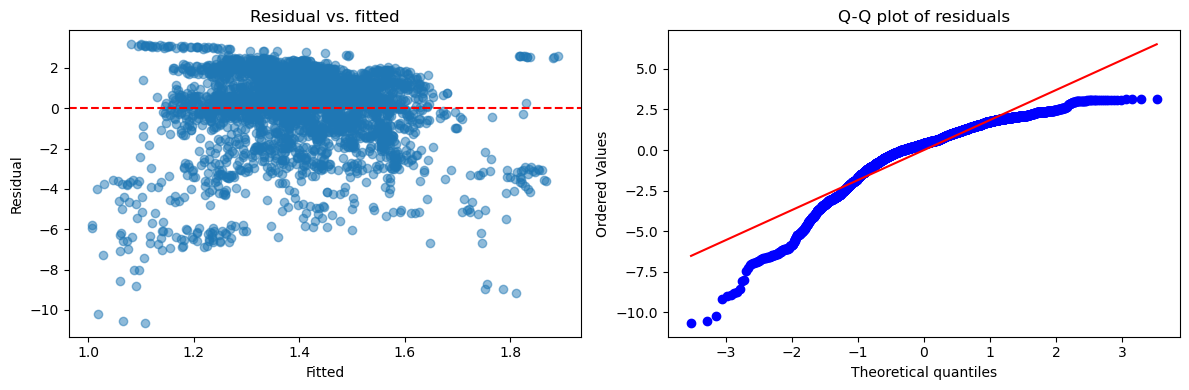

BP statistic: 121.21950066088792   p-value: 4.7590457735018806e-27


In [17]:
# Fit the log-log regression model. We are running regression on log_renew, log_gdp, and log_natural_resource_rents
df_clean = df[["log_renew", "log_gdp", "log_natural_resource_rents"]].replace(
    [np.inf, -np.inf], np.nan   
    #When we do log of the variables in the earlier cell, any zero values became -inf (because log(0) 
#is mathematically undefined/negative infinity). This line "[np.inf, -np.inf], np.nan" converts those -inf values to 
#NaN so they can be cleanly removed in the next step. 
).dropna()  #Drops any row where at least one of the three columns is missing


loglog = smf.ols(
    "log_renew ~ log_gdp + log_natural_resource_rents",
    data=df_clean
).fit()

print(loglog.summary())

#below code is running a regression diagnostic on a loglog regression model
#residual is the gap between the predicted value and the actual value.
import matplotlib.pyplot as plt
import scipy.stats as stats

from statsmodels.stats.diagnostic import het_breuschpagan
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Residual vs fitted 

#the below residual and fitted mdoel is trying to predict renewables_pct (what percentage of each contries total energy was renewable). 

axes[0].scatter(loglog.fittedvalues, loglog.resid, alpha=0.5)#each observation below is one country-year row in your dataset. 
#Ex: Algeria appears in the data from 1970 to 2022 so that's 52 separate dots on the plot.

axes[0].axhline(0, color="red", linestyle="--") #line which represents a perfect prediction model. 
axes[0].set_xlabel("Fitted") #predicted values of the model
axes[0].set_ylabel("Residual") #So if Norway 2010 actually had 65% renewable share but the model predicted 67%, the residual is −2. 
axes[0].set_title("Residual vs. fitted")
 
# Q-Q plot of residuals
stats.probplot(loglog.resid, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot of residuals")
 
plt.tight_layout()
plt.show()
 
# Breusch-Pagan test for heteroskedasticity
bp = het_breuschpagan(loglog.resid, loglog.model.exog)
print("BP statistic:", bp[0], "  p-value:", bp[1])


**Graphs interpretation interpretation:** 

1. The **residual and fitted plot** shows a funnel shape, this indicates that the model struggles much more to predict countries with low renewable share than countries with high renewable share. For example, the model can prediuct why renewable energy in countries like Norway, Iceland, and Denmark is so high because GDP and resource rents explain their path.

2. the **Q-Q plot** shows a heavy lower tail which indicates that the model dramaticaly overpredicts how much percetange renewbale energy should comprise of total energy in some countries. These are likely oil-rich countries where high GDP would normally predict higher renewables, but fossil fuel lock-in keeps renewable share extremely low despite wealth. The model has no variable capturing that lock-in effect, so those countries become large negative residuals dragging the tail down.

**Breusch-Pagan interpretation**

The Breusch-Pagan test formally tests whether the size of the residuals is systematically related to the predictor variables. The null hypothesis is that variance is constant. If the p-value is below 0.05 we reject this and conclude heteroskedasticity is present, meaning the model's standard errors are unreliable and p-values cannot be fully trusted. (Ex. to understand heteroskedasticity: Consider the relationship between a person's monthly income and their monthly expenditure on luxury items. High-income earners have far more financial flexibility; some may save their money while others spend heavily on luxury goods, resulting in high variance.Because the spread of spending habits widens as income rises, this dataset exhibits heteroskedasticity.

In our case the p-value is less than 0.05 therefore we can reject the null hypothesis (constant variance). In practical terms this means the standard errors printed in the regression table (0.025 for log_gdp and 0.017 for log_natural_resource_rents) cannot be trusted as reported, which means the t-statistics and p-values attached to them are also unreliable. Both coefficients currently appear significant (p = 0.026 and p = 0.000) but those significance levels may be wrong — heteroskedasticity can make variables look either more or less significant than they truly are.

The fix is to refit the model with HC3 robust standard errors, which recalculates the standard errors in a way that is valid even under heteroskedasticity, without changing the coefficients themselves. 


In [19]:
#refitting model so that regression results are valid even under heteroskedasticity
loglog_robust = smf.ols(
    'log_renew ~ log_gdp + log_natural_resource_rents',
    data=df_clean
).fit(cov_type='HC3')

print(loglog_robust.summary())

                            OLS Regression Results                            
Dep. Variable:              log_renew   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     3.273
Date:                Wed, 03 Jun 2026   Prob (F-statistic):             0.0380
Time:                        16:29:07   Log-Likelihood:                -6831.5
No. Observations:                3265   AIC:                         1.367e+04
Df Residuals:                    3262   BIC:                         1.369e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

**Conclusion**

The Variance Inflation Factors (VIFs) results give strong confidence that the three variables are measuring different things and that multicollinearity is not distorting the coefficients. What I trust most is the direction of the coefficients, that is, whether GDP and resource rents are positively or negatively associated with renewable share since these results hold even under heteroskedasticity. 

What I trust less is the precise magnitude of the p-values and confidence intervals, since if the Breusch-Pagan test flags heteroskedasticity the standard errors need to be corrected with HC3 robust errors before drawing firm conclusions. Additionally the model only includes two predictors, so other variabless like geography, climate, and political institutions likely also drive renewable adoption and the coefficient on GDP and rents. 